Dataset: E-Commerce Shipping Data
Guiding Question: What factors (warehouse block, mode of shipment, product weight, discount offered) most accurately predict whether a shipment will arrive on time?

In [79]:
import pandas as pd
df = pd.read_csv("Train.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [81]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [82]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

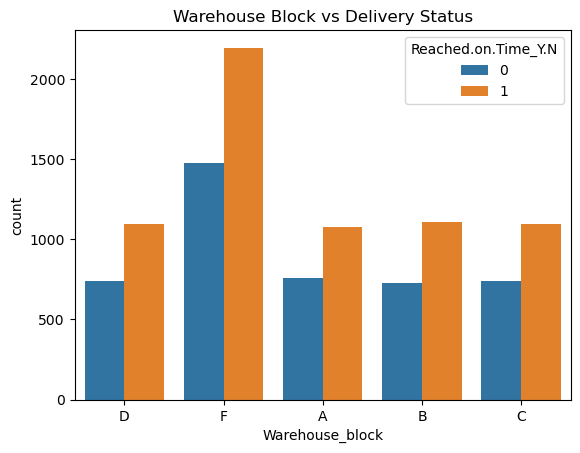

In [83]:
# Bar Charts / Count Plots
sns.countplot(
    x='Warehouse_block',
    hue='Reached.on.Time_Y.N',
    data=df
)
plt.title("Warehouse Block vs Delivery Status")
plt.show()
# sns.countplot(
#     x='Mode_of_Shipment',
#     hue='Reached.on.Time_Y.N',
#     data=df
# )
# plt.title("Shipment Mode vs Delivery Status")
# plt.show()

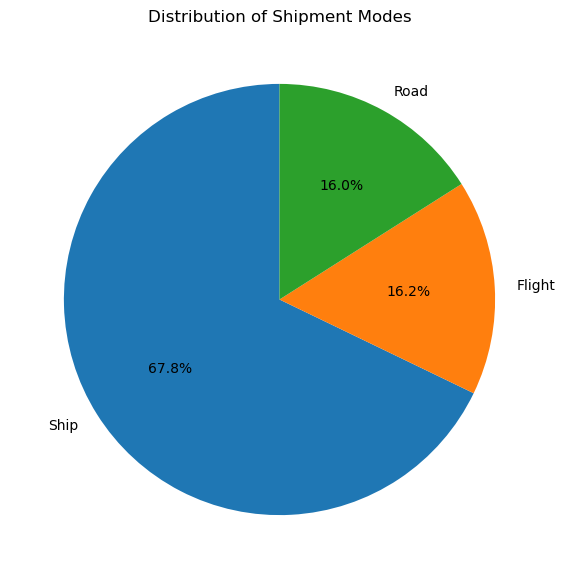

In [84]:
shipment_counts = df['Mode_of_Shipment'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    shipment_counts,
    labels=shipment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Shipment Modes')
plt.show()

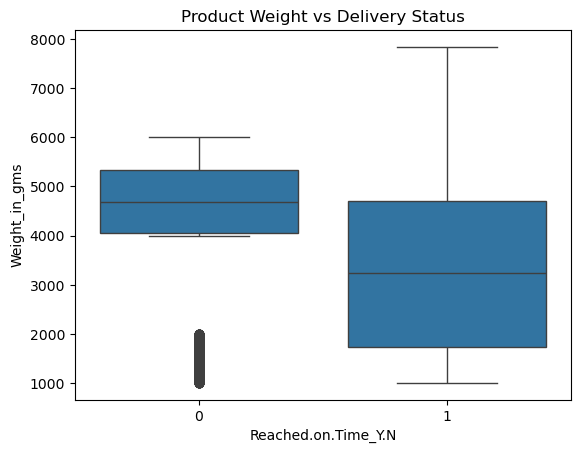

In [85]:
sns.boxplot(
    x='Reached.on.Time_Y.N',
    y='Weight_in_gms',
    data=df
)
plt.title("Product Weight vs Delivery Status")
plt.show()
# sns.boxplot(
#     x='Reached.on.Time_Y.N',
#     y='Discount_offered',
#     data=df
# )
# plt.title("Discount Offered vs Delivery Status")
# plt.show()

<Axes: xlabel='Discount_offered', ylabel='Weight_in_gms'>

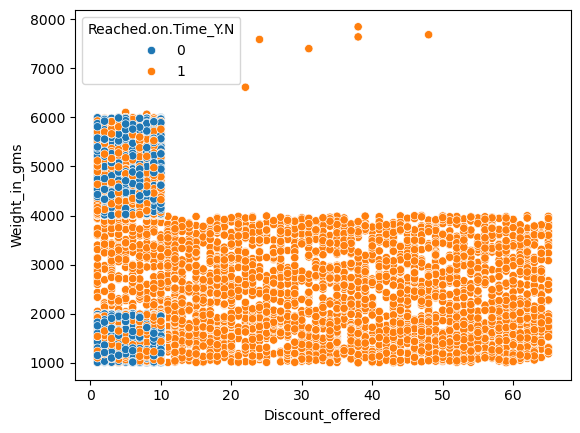

In [86]:
sns.scatterplot(
    x='Discount_offered',
    y='Weight_in_gms',
    hue='Reached.on.Time_Y.N',
    data=df
)

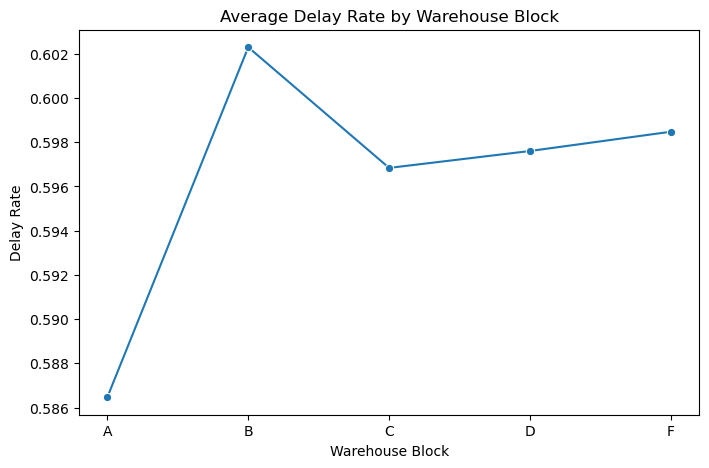

In [87]:
warehouse_delay = (
    df.groupby('Warehouse_block')['Reached.on.Time_Y.N']
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.lineplot(
    data=warehouse_delay,
    x='Warehouse_block',
    y='Reached.on.Time_Y.N',
    marker='o'
)
plt.title('Average Delay Rate by Warehouse Block')
plt.xlabel('Warehouse Block')
plt.ylabel('Delay Rate')
plt.show()

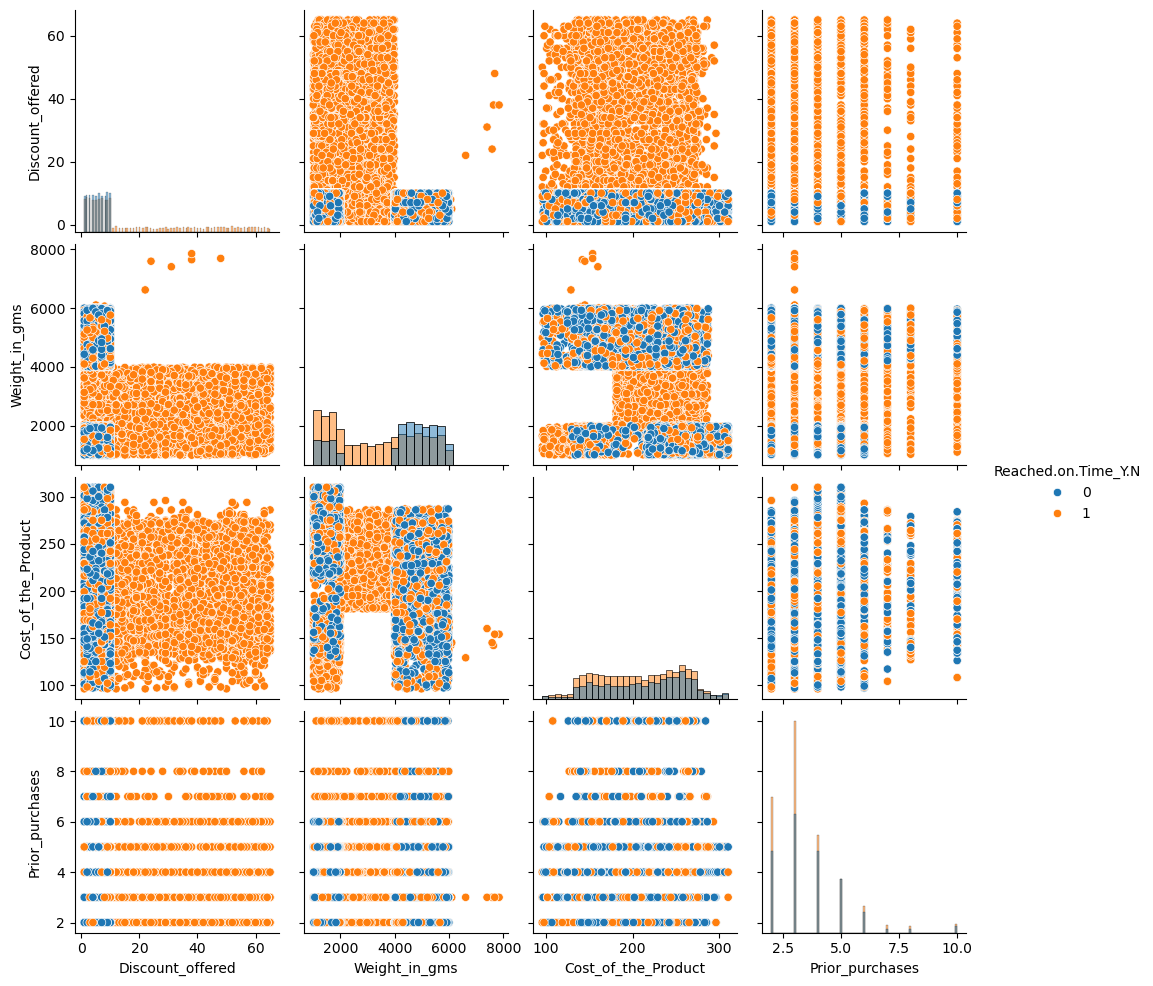

In [93]:
pair_df = df[[
    'Discount_offered',
    'Weight_in_gms',
    'Cost_of_the_Product',
    'Prior_purchases',
    'Reached.on.Time_Y.N'
]]
sns.pairplot(
    pair_df,
    hue='Reached.on.Time_Y.N',
    diag_kind='hist'
)
plt.show()

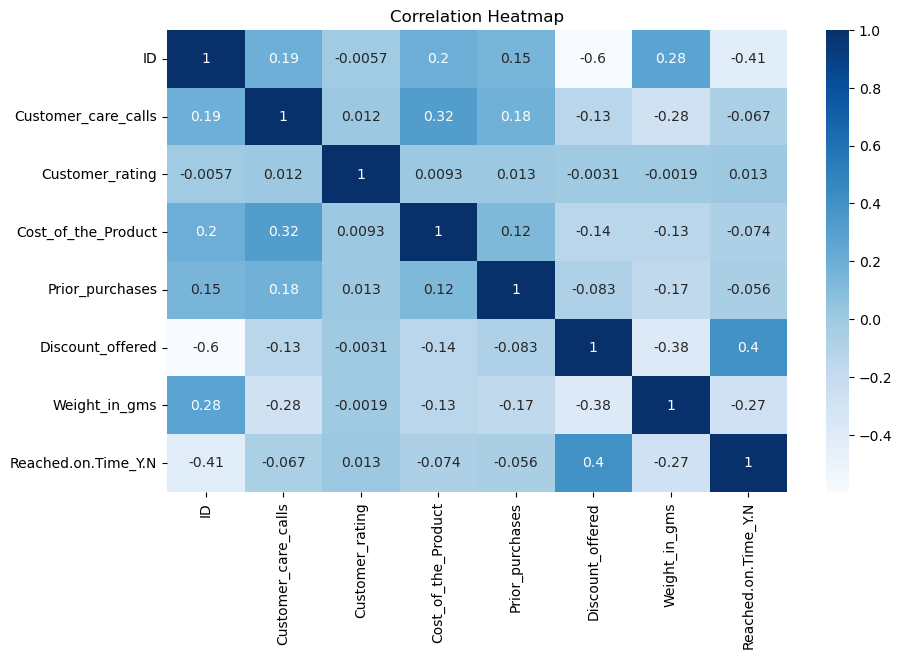

In [94]:
# plt.figure(figsize=(10,6))
# sns.heatmap(
#     df.corr(numeric_only=True),
#     annot=True,
#     cmap='Blues'
# )
# plt.title("Correlation Heatmap")
# plt.show()